In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

## Data Loading

In [2]:
df = pd.read_csv('/home/chinmay/SuperstoreProject/Data/SuperstoreCleanDataWithSegment.csv', parse_dates=['OrderDate'])

## Quick Summary

In [3]:
print(df.shape)

(1000, 28)


In [4]:
print(df.dtypes)

RowID                       int64
OrderID                    object
OrderDate          datetime64[ns]
ShipDate                   object
ShipMode                   object
CustomerID                 object
CustomerName               object
CustomerType               object
Country                    object
City                       object
State                      object
PostalCode                  int64
Region                     object
ProductID                  object
ProductCategory            object
SubCategory                object
ProductName                object
Sales                     float64
Quantity                    int64
Discount                  float64
Profit                    float64
Recency                     int64
Frequency                   int64
Monetary                  float64
RScore                      int64
FScore                      int64
MScore                      int64
Segment                    object
dtype: object


In [5]:
df.head()

,RowID,OrderID,OrderDate,ShipDate,ShipMode,CustomerID,CustomerName,CustomerType,Country,City,...,Quantity,Discount,Profit,Recency,Frequency,Monetary,RScore,FScore,MScore,Segment
0,1,CA-2014-103278,2016-02-26,2016-03-02,First Class,CG-53283,Kate Taylor,Corporate,United States,Phoenix,...,9,0.50,898.98,675,1,3021.48,3,3,3,Loyal
1,2,CA-2016-132098,2017-06-14,2017-06-21,First Class,CG-24855,Tom Anderson,Corporate,United States,Seattle,...,2,0.23,-952.67,201,1,4986.74,5,1,5,Regular
2,3,CA-2015-118289,2016-05-06,2016-05-08,Standard Class,CG-73113,Jane Doe,Corporate,United States,Phoenix,...,2,0.14,410.20,605,1,4600.80,3,4,5,Loyal
3,4,CA-2014-188696,2015-05-24,2015-05-26,First Class,CG-98503,Sarah Williams,Home Office,United States,Seattle,...,4,0.01,260.62,953,1,4689.71,2,5,5,At Risk
4,5,CA-2014-177397,2014-11-24,2014-12-08,Second Class,CG-72759,Chris Wilson,Consumer,United States,Indianapolis,...,2,0.29,943.64,1134,1,4643.75,2,4,5,At Risk


In [6]:
df.describe()

,RowID,OrderDate,PostalCode,Sales,Quantity,Discount,Profit,Recency,Frequency,Monetary,RScore,FScore,MScore
count,1000.000000,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,2016-01-27 08:36:57.600000,53704.321000,2508.127580,5.560000,0.248340,220.233850,700.42800,1.018000,2562.854850,3.015000,3.016000,3.015000
min,1.000000,2014-01-07 00:00:00,10220.000000,10.050000,1.000000,0.000000,-973.370000,1.00000,1.000000,10.050000,1.000000,1.000000,1.000000
25%,250.750000,2015-02-17 12:00:00,30983.750000,1174.407500,3.000000,0.120000,-90.727500,339.25000,1.000000,1181.032500,2.000000,2.000000,2.000000
50%,500.500000,2016-02-12 00:00:00,52376.000000,2543.540000,6.000000,0.260000,132.695000,684.50000,1.000000,2603.335000,3.000000,3.000000,3.000000
75%,750.250000,2017-01-18 12:00:00,75073.500000,3772.297500,8.000000,0.372500,509.182500,1045.50000,1.000000,3820.132500,4.000000,4.000000,4.000000
max,1000.000000,2017-12-31 00:00:00,99939.000000,4995.710000,10.000000,0.500000,1846.550000,1455.00000,2.000000,9108.350000,5.000000,5.000000,5.000000
std,288.819436,NaN,25783.287761,1469.193051,2.850355,0.146655,513.287724,415.81808,0.133018,1546.081663,1.418022,1.421888,1.420843


## Plots

### Sales Distribution

Text(0, 0.5, 'Number of Orders')

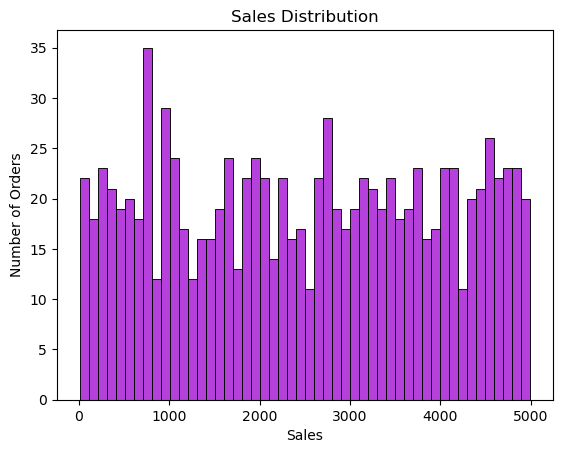

In [7]:
sns.histplot(df['Sales'], bins = 50, color = '#9e00cf')
plt.title('Sales Distribution')
plt.xlabel('Sales')
plt.ylabel('Number of Orders')

### Profit Distribution

Text(0, 0.5, 'Number of Orders')

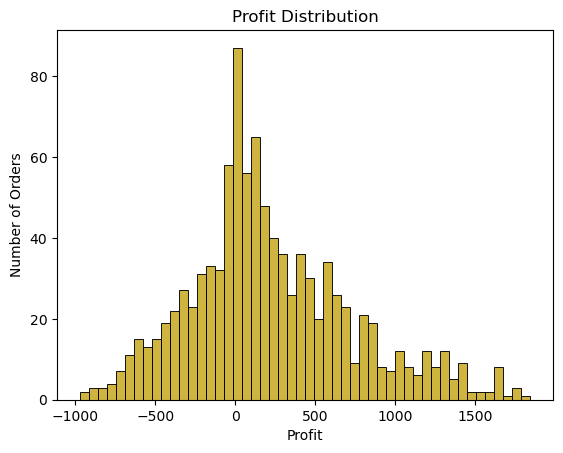

In [8]:
sns.histplot(df['Profit'], bins = 50, color = '#bf9c00')
plt.title('Profit Distribution')
plt.xlabel('Profit')
plt.ylabel('Number of Orders')

### Box Plots for Sales

Text(0, 0.5, 'Sales')

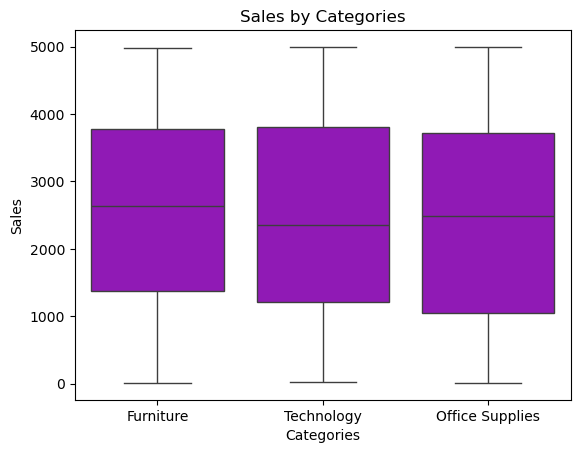

In [9]:
sns.boxplot(data = df, x = 'ProductCategory', y = 'Sales', color = '#9e00cf')
plt.title('Sales by Categories')
plt.xlabel('Categories')
plt.ylabel('Sales')

### Box Plot for Profits

Text(0, 0.5, 'Profit')

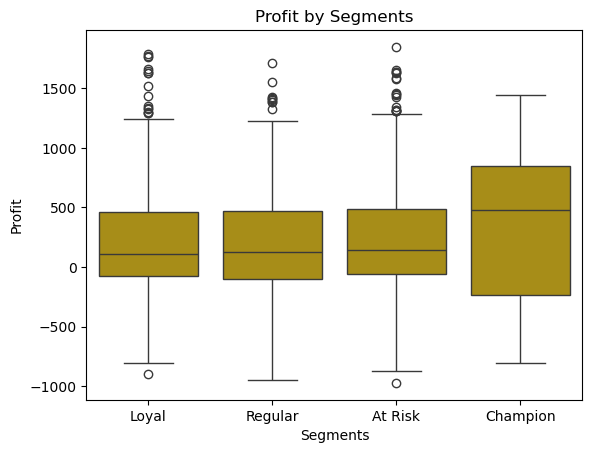

In [10]:
sns.boxplot(data = df, x = 'Segment', y = 'Profit', color = '#bf9c00')
plt.title('Profit by Segments')
plt.xlabel('Segments')
plt.ylabel('Profit')

### Categorical Counts

In [11]:
print(df['ProductCategory'].value_counts())

ProductCategory
Technology         341
Office Supplies    338
Furniture          321
Name: count, dtype: int64


In [12]:
print(df['Region'].value_counts())

Region
West       284
Central    247
East       244
South      225
Name: count, dtype: int64


In [13]:
print(df['Segment'].value_counts())

Segment
At Risk     397
Loyal       302
Regular     232
Champion     69
Name: count, dtype: int64


## Trend Analysis

### Monthly Sales Trend

In [14]:
df['Month'] = df['OrderDate'].dt.to_period('M')

In [15]:
MonthlySales = df.groupby('Month')['Sales'].sum()

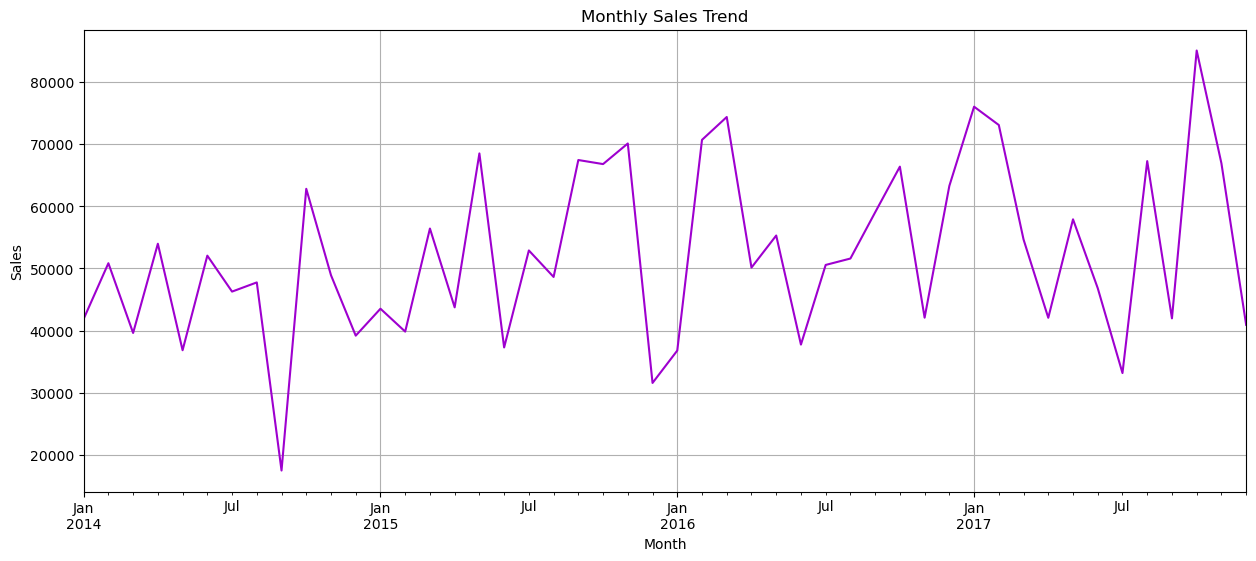

In [16]:
MonthlySales.plot(figsize=(15,6), color = '#9e00cf')
plt.title('Monthly Sales Trend') 
plt.xlabel('Month') 
plt.ylabel('Sales')
plt.grid()

### Monthly Profit Trend

In [17]:
MonthlyProfit = df.groupby('Month')['Profit'].sum()

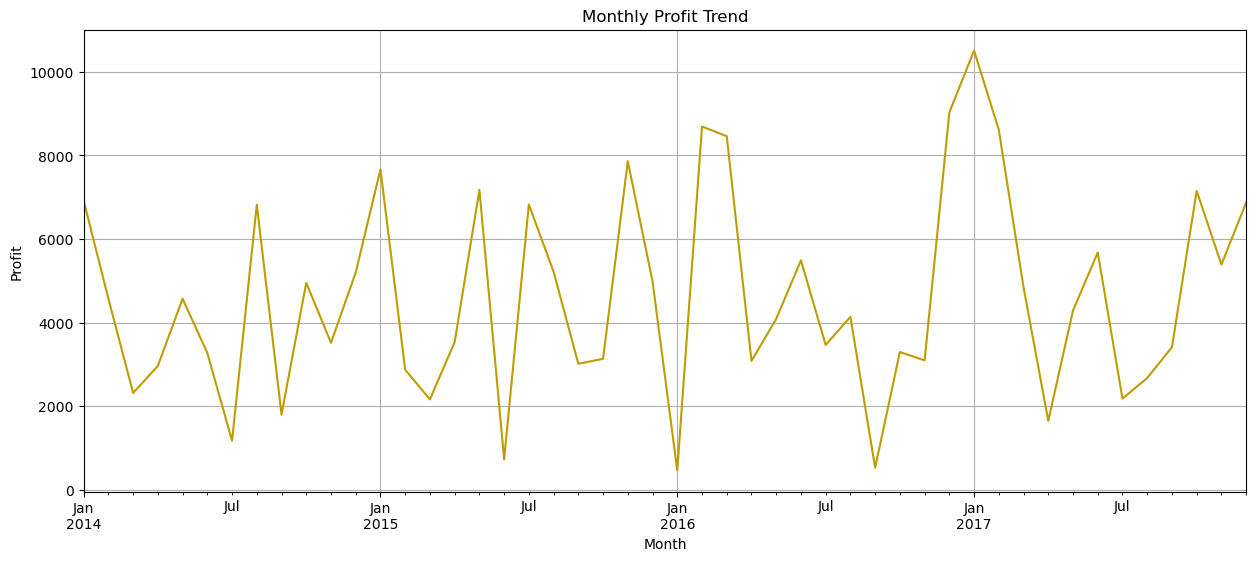

In [18]:
MonthlyProfit.plot(figsize=(15,6), color='#bf9c00')
plt.title('Monthly Profit Trend')
plt.xlabel('Month')
plt.ylabel('Profit')
plt.grid()

## Customer Segmentation Visuals

### Segment Distribution

In [19]:
SegmentCounts = df.groupby('Segment')['CustomerID'].nunique()

Text(0, 0.5, '')

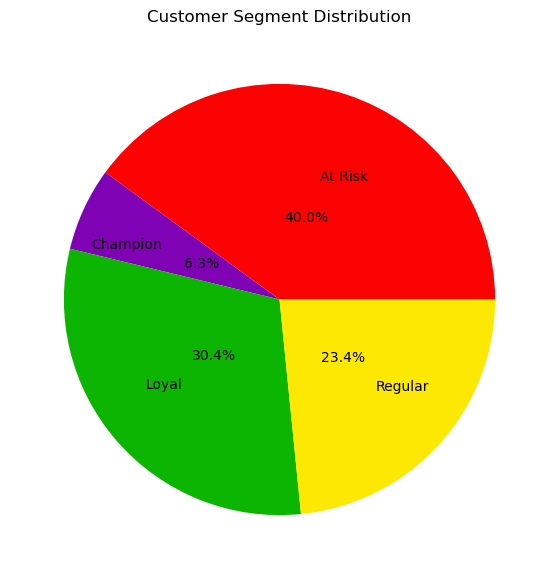

In [20]:
SegmentCounts.plot.pie(autopct='%1.1f%%', figsize=(7,7), labeldistance = 0.6, pctdistance = 0.4,
                      colors = ['#fc0303', '#7f02b5', '#0bb502', '#fce803'])
plt.title('Customer Segment Distribution')
plt.ylabel('')

## Correlation Matrix

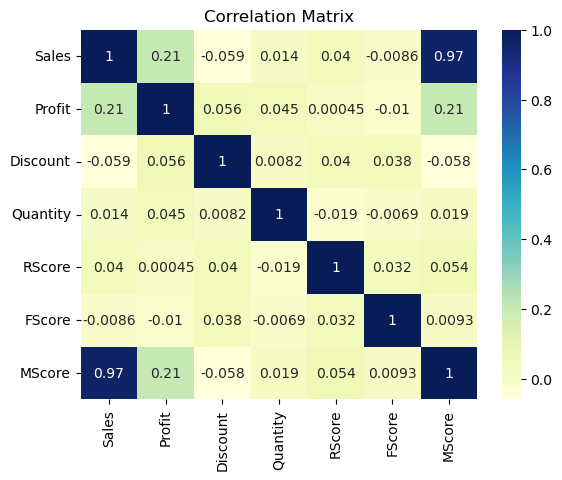

In [21]:
corr = df[['Sales', 'Profit', 'Discount', 'Quantity', 'RScore', 'FScore', 'MScore']].corr()
sns.heatmap(corr, annot=True, cmap='YlGnBu')
plt.title('Correlation Matrix')
plt.show()

### Outlier and Anomaly Checks

In [22]:
df['SalesZ'] = zscore(df['Sales'])

In [23]:
print('Sales outliers (|z| > 3):', df[abs(df['SalesZ']) > 3].shape[0])

Sales outliers (|z| > 3): 0
